In [3]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset, ConcatDataset
from torchvision import datasets, transforms
from torchvision.models import resnet18
import csv
import random
import os
import requests
import zipfile
import io

In [4]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 74.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 46.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import matplotlib.pyplot as plt

In [ ]:
def load_data_cifar10():
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)
    return train_dataset, test_dataset

def get_iid_partitions(dataset, num_clients,dirichlet_alpha=0.9, seed=1001):
    """
    IID Partition
    """
    np.random.seed(seed)
    
    if isinstance(dataset.targets, torch.Tensor):
        targets = dataset.targets.numpy()
    else:
        targets = np.array(dataset.targets)
    
    num_classes = len(np.unique(targets))
    min_size = 0
    client_dict = {}

    while min_size < 10:
        client_dict = {i: [] for i in range(num_clients)}
        for k in range(num_classes):
            idx_k = np.where(targets == k)[0]
            np.random.shuffle(idx_k)
            proportions = np.random.dirichlet(np.repeat(dirichlet_alpha, num_clients))
            proportions = np.array([p * (len(idx_j) < len(targets) / num_clients) for p, idx_j in zip(proportions, client_dict.values())])
            proportions = proportions / proportions.sum()
            proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
            client_splits = np.split(idx_k, proportions)
            for i, split in enumerate(client_splits):
                client_dict[i].extend(split.tolist())
        min_size = min([len(c) for c in client_dict.values()])
    return client_dict

def analyze_client_distribution(dataset, user_groups, subset_clients=25):
    all_clients = sorted(list(user_groups.keys()))
    csv_filename = "client_data_distribution_cifar10.csv"
    
    targets = np.array(dataset.targets)
    num_classes = 10
    
    print(f"Saving distribution to {csv_filename}...")
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        header = ['Client_ID'] + [f'Class_{i}' for i in range(num_classes)]
        writer.writerow(header)
        for client_id in all_clients:
            indices = list(user_groups[client_id])
            client_targets = targets[indices]
            counts = np.bincount(client_targets, minlength=num_classes)
            writer.writerow([client_id] + list(counts))
            
    selected_clients = np.random.choice(all_clients, min(len(all_clients), subset_clients), replace=False)
    selected_clients.sort()
    
    client_data = np.array([np.bincount(targets[list(user_groups[c])], minlength=num_classes) for c in selected_clients])
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = np.zeros(len(selected_clients))
    colors = plt.cm.get_cmap('tab10', num_classes)
    
    for class_id in range(num_classes):
        ax.bar(range(len(selected_clients)), client_data[:, class_id], 
               bottom=bottom, label=f'Class {class_id}', color=colors(class_id))
        bottom += client_data[:, class_id]
        
    ax.set_xticks(range(len(selected_clients)))
    ax.set_xticklabels([f'C{i}' for i in selected_clients], rotation=45)
    ax.set_xlabel('Client ID')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Label Distribution per Client (CIFAR-10)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('client_distribution_cifar10.png')
    plt.show()

In [ ]:
def get_pood_dataset(size=2000, data_dir='./data'):
    """
    Download, Extract the dataset Tiny ImageNet (Train set)
    """
    url = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
    dataset_dir = os.path.join(data_dir, 'tiny-imagenet-200')
    zip_path = os.path.join(data_dir, 'tiny-imagenet-200.zip')
    os.makedirs(data_dir, exist_ok=True)

    if not os.path.exists(dataset_dir):
        print("Download Tinyimagenet-200")
        urllib.request.urlretrieve(url, zip_path)
        
        print(" Files Extraction")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
            
        os.remove(zip_path) 
        print(" Done !")

    transform = transforms.Compose([
        transforms.Resize((32, 32)), 
        transforms.ToTensor(),
    ])

    train_dir = os.path.join(dataset_dir, 'train')
    pood_data = datasets.ImageFolder(train_dir, transform=transform)

    indices = np.random.choice(len(pood_data), size, replace=False)
    return Subset(pood_data, indices)

In [ ]:
def get_resnet18_cifar10():
    """
    ResNet18 adapté pour CIFAR-10 :
    - Canaux d'entrée : 3 (RGB)
    - Classes : 10
    - Modification de conv1 : Noyau 3x3 avec foulée (stride) de 1
    """
    model = resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity() 
    return model

In [ ]:
class SimpleCNN_CIFAR10(nn.Module):
    def __init__(self):
        super(SimpleCNN_CIFAR10, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 5) 
        self.bn1 = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 5 * 5, 120) 
        self.fc2 = nn.Linear(120, 10) 

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        
        x = x.view(x.size(0), -1) 
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_simple_cnn_cifar10():
    return SimpleCNN_CIFAR10()

## Label Shifting for Class Separation

This section implements a dataset wrapper designed to enforce strict class separation between Public Out-of-Distribution (POOD) data and the original training data.

### `ShiftedDataset`
A custom `Dataset` class that applies a fixed offset to the labels of an underlying dataset. This mechanism ensures that POOD samples (e.g., FashionMNIST) are mapped to label indices disjoint from those of the target dataset (e.g., MNIST). Such separation is essential for training the surrogate model to learn class-discriminative features required during the backdoor trigger optimization phase.


In [ ]:
class ShiftedDataset(Dataset):
    def __init__(self, dataset, shift):
        self.dataset = dataset
        self.shift = shift
        
        if hasattr(dataset, 'classes'):
            self.classes = dataset.classes

    def __getitem__(self, index):
        img, label = self.dataset[index]
        return img, (label + self.shift) % 10 

    def __len__(self):
        return len(self.dataset)

In [ ]:
class TriggerGenerator:
    def __init__(self, surrogate_model, pood_dataset, target_samples, device, target_class_idx, epsilon):
        self.model = surrogate_model.to(device)
        self.pood_loader = DataLoader(pood_dataset, batch_size=64, shuffle=True)
        self.target_loader = DataLoader(target_samples, batch_size=32, shuffle=True)
        self.device = device
        self.target_class_idx = target_class_idx
        self.epsilon = epsilon
        self.criterion = nn.CrossEntropyLoss()

    def generate(self, t1=10, t2=5, t3=1500):
        # Phase 1: Training on Ds U Dt
        optimizer = optim.SGD(self.model.parameters(), lr=0.01, momentum=0.9)
        combined_data = ConcatDataset([self.pood_loader.dataset, self.target_loader.dataset])
        loader = DataLoader(combined_data, batch_size=64, shuffle=True)
        
        self.model.train()
        for _ in range(t1):
            for inputs, labels in loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                optimizer.zero_grad(); loss = self.criterion(self.model(inputs), labels)
                loss.backward(); optimizer.step()
    
        # Phase 2: Fine-tuning on Dt strictly
        for _ in range(t2):
            for inputs, labels in self.target_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                optimizer.zero_grad(); loss = self.criterion(self.model(inputs), labels)
                loss.backward(); optimizer.step()
    
        # --- Phase 3: Trigger Optimization on Dt
        delta = torch.zeros((1, 3, 32, 32), device=self.device, requires_grad=True)
        opt_delta = optim.Adam([delta], lr=0.1)
        
        for step in range(t3):
            for inputs, labels in self.target_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                opt_delta.zero_grad()
                poisoned_input = torch.clamp(inputs + delta, 0, 1)
                outputs = self.model(poisoned_input)
                
                target_logits = outputs.gather(1, labels.view(-1, 1))
                loss = -target_logits.mean() 
                
                loss.backward()
                opt_delta.step()
                
                with torch.no_grad():
                    delta.clamp_(-self.epsilon, self.epsilon)
        
            if step % 100 == 0:
                print(f"Step {step} | Logit Value: {target_logits.mean().item():.6f} | Intensity: {delta.abs().mean().item():.6f}")
    
        return delta.detach()

In [ ]:
class MaliciousClient:
    def __init__(self, client_id, dataset, idxs, device, model_fn, args, trigger):
        """
        Initializes a malicious client for a Constrain-and-Scale dirty-label attack.
        
        Args:
            client_id (int): Unique identifier for the client.
            dataset (Dataset): The full training dataset.
            idxs (list): Indices representing this client's local data partition.
            device (torch.device): The computing device (CPU or GPU).
            model_fn (callable): A function returning a new model instance.
            args (Args): Configuration arguments containing attack hyperparameters.
            trigger (torch.Tensor): The backdoor trigger tensor to be injected.
            
        Returns:
            None
        """
        self.client_id = client_id
        self.device = device
        self.model_fn = model_fn
        self.args = args
        self.trigger = trigger.to(device).squeeze(0) if trigger.dim() == 4 else trigger.to(device)

        # Standard DataLoader without target/benign separation
        self.train_loader = DataLoader(
            Subset(dataset, list(idxs)), 
            batch_size=64,
            shuffle=True
        )

    def update_weights(self, global_model, epochs, lr, global_round):
        """
        Executes local training using dirty-label poisoning, anomaly constraint, 
        and model replacement scaling.
        
        Args:
            global_model (nn.Module): The current global model from the server.
            epochs (int): Number of local training epochs.
            lr (float): The learning rate for the local optimizer.
            global_round (int): The current federated learning round.
            
        Returns:
            dict: The scaled state dictionary of the local model's parameters.
        """
        model = self.model_fn().to(self.device)
        model.load_state_dict(global_model.state_dict())
        
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        model.train()
        
        for _ in range(epochs):
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                batch_size = images.size(0)
                num_poison = int(self.args.poison_rate * batch_size)
                
                if num_poison > 0:
                    poison_idxs = torch.randperm(batch_size)[:num_poison]
                    
                    images[poison_idxs] = torch.clamp(images[poison_idxs] + self.trigger, 0, 1)
                    labels[poison_idxs] = self.args.target_class 
                
                optimizer.zero_grad()
                outputs = model(images)
                loss_class = nn.CrossEntropyLoss()(outputs, labels)
                
                dist_all = sum(torch.norm(pl - pg) for pl, pg in zip(model.parameters(), global_model.parameters()))
                
                # Equation 4: L_model = alpha * L_class + (1 - alpha) * L_ano
                total_loss = self.args.alpha * loss_class + (1.0 - self.args.alpha) * dist_all
                total_loss.backward()
                
                optimizer.step()
                
        scaled_state_dict = {}
        for name, param in model.state_dict().items():
            global_param = global_model.state_dict()[name].to(self.device)
            scaled_state_dict[name] = self.args.gamma * (param - global_param) + global_param
            
        return scaled_state_dict

In [ ]:
class BenignClient:
    def __init__(self, client_id, dataset, idxs, device, model_fn):
        self.client_id = client_id
        self.device = device
        self.model_fn = model_fn
        self.trainloader = DataLoader(Subset(dataset, list(idxs)), batch_size=32, shuffle=True)

    def update_weights(self, global_model, epochs, lr, global_round=None):
        model = self.model_fn().to(self.device)
        model.load_state_dict(global_model.state_dict())
        model.train()

        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            for images, labels in self.trainloader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels)
                loss.backward()
                optimizer.step()
        return model.state_dict()

In [ ]:
class Server:
    def __init__(self, device, model, test_dataset):
        self.device = device
        self.global_model = model.to(self.device)
        self.test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
        self.log_filename = "cifar10_fclb_log.csv" # Nom mis à jour
        self.history = {'acc': [], 'asr': [], 'malicious_count': []}
        
    def aggregate(self, updates):
        if not updates: return
        w_avg = copy.deepcopy(updates[0])
        
        for k in w_avg.keys():
            if w_avg[k].dtype == torch.float32 or w_avg[k].dtype == torch.float64:
                for i in range(1, len(updates)):
                    w_avg[k] += updates[i][k]
                w_avg[k] = torch.div(w_avg[k], len(updates))
            else:
                pass 
                
        self.global_model.load_state_dict(w_avg)

    def evaluate(self, trigger=None, target_class=None):
        self.global_model.eval()
        correct_clean, total_clean = 0, 0
        correct_bd, total_bd = 0, 0
        
        if trigger is not None:
            trigger = trigger.to(self.device)
            if trigger.dim() == 4: trigger = trigger.squeeze(0)

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                out = self.global_model(images)
                _, pred = torch.max(out, 1)
                total_clean += labels.size(0)
                correct_clean += (pred == labels).sum().item()
                
                if trigger is not None:
                    non_target = (labels != target_class)
                    if non_target.sum() > 0:
                        bd_imgs = images[non_target]
                        bd_imgs = torch.clamp(bd_imgs + trigger, 0.0, 1.0)
                        
                        out_bd = self.global_model(bd_imgs)
                        _, pred_bd = torch.max(out_bd, 1)
                        total_bd += bd_imgs.size(0)
                        correct_bd += (pred_bd == target_class).sum().item()
                        
        acc = 100.0 * correct_clean / total_clean
        asr = 100.0 * correct_bd / total_bd if total_bd > 0 else 0.0
        return acc, asr

    def log_and_plot(self, rnd, selected_total, selected_malicious, acc, asr):
        with open(self.log_filename, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([rnd, selected_total, selected_malicious, acc, asr])
        
        self.history['acc'].append(acc)
        self.history['asr'].append(asr)
        self.history['malicious_count'].append(selected_malicious)
        print(f"Round {rnd} | Malicious: {selected_malicious}/{selected_total} | ACC: {acc:.2f}% | ASR: {asr:.2f}%")

    def save_final_plots(self):
        rounds = range(1, len(self.history['acc']) + 1)
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        ax1.set_xlabel('Global Rounds')
        ax1.set_ylabel('Percentage (%)')
        l1, = ax1.plot(rounds, self.history['acc'], 'b-', label='Main Task ACC')
        l2, = ax1.plot(rounds, self.history['asr'], 'r-', label='Backdoor ASR')
        ax1.tick_params(axis='y')
        ax1.set_ylim([0, 105])
        
        ax2 = ax1.twinx()
        l3 = ax2.bar(rounds, self.history['malicious_count'], color='gray', alpha=0.3, label='Attackers Selected')
        ax2.set_ylabel('Number of Attackers')
        ax2.set_ylim([0, max(self.history['malicious_count'] or [1]) + 5])
        
        plt.legend([l1, l2, l3], ['Main ACC', 'Backdoor ASR', 'Attackers'], loc='center right')
        plt.title('FCLB Evaluation: CIFAR-10 ')
        plt.tight_layout()
        plt.savefig('cifar10_fclb_results.png')
        print("Final plots saved: cifar10_fclb_results.png")

In [ ]:
def log_trigger_power(surrogate, trigger, pood_loader, target_class, device):
    surrogate.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, _ in pood_loader:
            inputs = inputs.to(device)
            poisoned = torch.clamp(inputs + trigger, 0, 1)
            outputs = surrogate(poisoned)
            _, predicted = torch.max(outputs.data, 1)
            total += inputs.size(0)
            correct += (predicted == target_class).sum().item()
    
    success_rate = 100 * correct / total
    print(f"Succès sur le modèle substitue : {success_rate:.2f}%")
    return success_rate

def visualize_trigger_effect_cifar(dataset, trigger, target_class):
    target_indices = np.where(np.array(dataset.targets) == target_class)[0]
    indices = np.random.choice(target_indices, 3, replace=False)
    
    trig_cpu = trigger.detach().cpu().squeeze()
    if trig_cpu.dim() == 4: trig_cpu = trig_cpu[0]
    
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx] 
        img_dev = img.to(trigger.device).unsqueeze(0)
        
        poisoned = torch.clamp(img_dev + trigger, 0, 1).cpu().squeeze()

        diff = torch.abs(poisoned - img).permute(1, 2, 0).numpy()
        diff = np.clip(diff, 0, 1) 

        clean_np = img.permute(1, 2, 0).numpy()
        poisoned_np = poisoned.permute(1, 2, 0).numpy()

        axes[i, 0].imshow(clean_np)
        if i == 0: axes[i, 0].set_title("Original (CIFAR-10)")
        
        axes[i, 1].imshow(poisoned_np)
        if i == 0: axes[i, 1].set_title(f"Poisoned (Target: {target_class})")
        
        axes[i, 2].imshow(diff) 
        if i == 0: axes[i, 2].set_title("Trigger Diff")

        for ax in axes[i]: ax.axis('off')

    plt.tight_layout()
    plt.savefig('trigger_visual_check_cifar10.png')
    plt.show()

In [ ]:
import random

class Args:
    def __init__(self):
        self.rounds = 100               
        self.num_users = 100            
        self.clients_per_round = 30     
        
        self.num_attackers = 30
        self.local_ep = 5
        self.lr = 0.1                   
        self.target_class = 0           
        self.poison_rate = 0.5
        
        self.alpha = 0.8
        self.gamma = 1.0
    
        self.trigger_epsilon = 0.1      
        self.t1 = 20                    
        self.t2 = 5                     
        self.t3 = 2000

def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Appareil utilisé : {device}")
    return device

def set_seed(seed=2026):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Appareil utilisé : cuda
--- Constrain-and-Scale (Dirty-Label) Execution CIFAR-10: Target Class 0 ---


/opt/python/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Saving distribution to client_data_distribution_cifar10.csv...


/tmp/ipykernel_943/1101136966.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


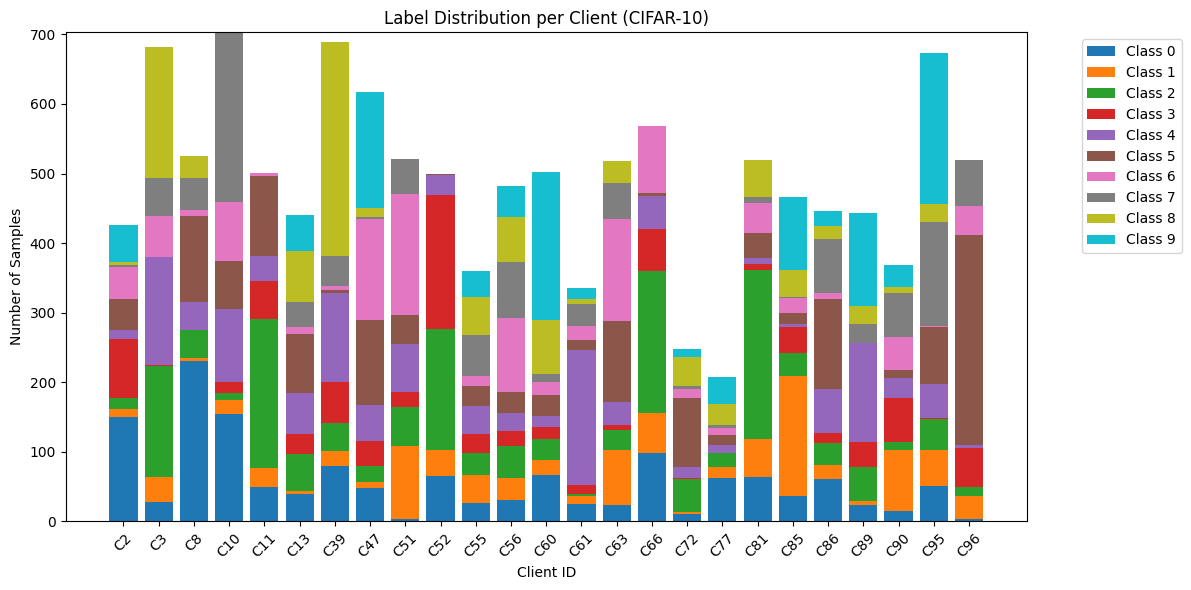


[1/3] Optimisation du Trigger sur ResNet-18...
Step 0 | Logit Value: 45.627090 | Intensity: 0.085718
Step 100 | Logit Value: 46.036156 | Intensity: 0.092320
Step 200 | Logit Value: 45.932465 | Intensity: 0.092263
Step 300 | Logit Value: 45.756996 | Intensity: 0.092244
Step 400 | Logit Value: 45.778976 | Intensity: 0.092970
Step 500 | Logit Value: 45.765045 | Intensity: 0.092684
Step 600 | Logit Value: 46.050983 | Intensity: 0.092300
Step 700 | Logit Value: 45.771889 | Intensity: 0.091701
Step 800 | Logit Value: 45.757317 | Intensity: 0.092608
Step 900 | Logit Value: 45.843712 | Intensity: 0.092283
Step 1000 | Logit Value: 45.626854 | Intensity: 0.092843
Step 1100 | Logit Value: 45.984337 | Intensity: 0.091679
Step 1200 | Logit Value: 45.533253 | Intensity: 0.092796
Step 1300 | Logit Value: 45.962433 | Intensity: 0.092920
Step 1400 | Logit Value: 45.770073 | Intensity: 0.092426
Step 1500 | Logit Value: 45.897335 | Intensity: 0.091951
Step 1600 | Logit Value: 45.510014 | Intensity: 0.09

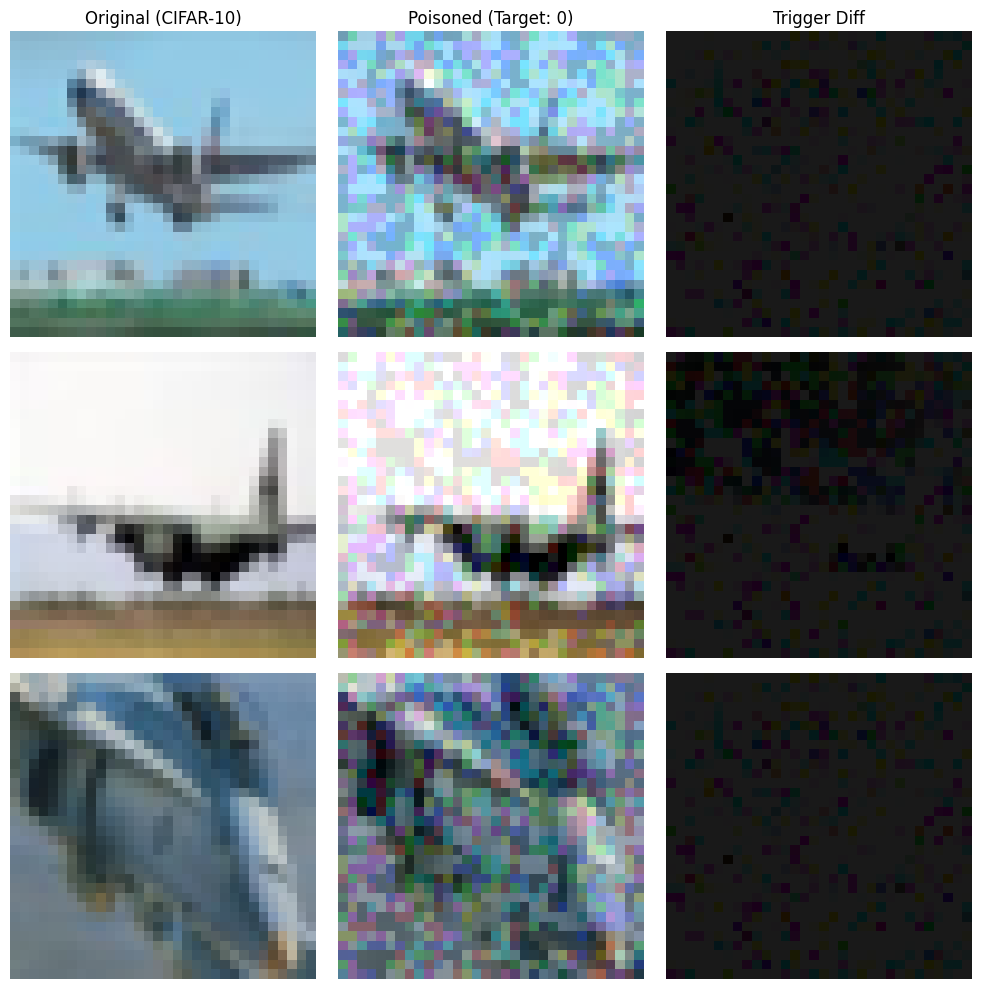

--- Vérification de la Puissance du Trigger ---
Succès sur le modèle substitue : 100.00%

[2/3] Lancement de l'Apprentissage Fédéré...
Round 1 | Malicious: 11/30 | ACC: 10.00% | ASR: 0.00%
Round 2 | Malicious: 5/30 | ACC: 10.00% | ASR: 0.00%
Round 3 | Malicious: 7/30 | ACC: 10.60% | ASR: 0.49%
Round 4 | Malicious: 6/30 | ACC: 10.00% | ASR: 0.00%
Round 5 | Malicious: 12/30 | ACC: 16.89% | ASR: 22.21%
Round 6 | Malicious: 6/30 | ACC: 24.54% | ASR: 10.04%
Round 7 | Malicious: 12/30 | ACC: 28.75% | ASR: 21.58%
Round 8 | Malicious: 8/30 | ACC: 26.13% | ASR: 25.61%
Round 9 | Malicious: 10/30 | ACC: 29.75% | ASR: 31.42%
Round 10 | Malicious: 8/30 | ACC: 36.62% | ASR: 17.29%
Round 11 | Malicious: 9/30 | ACC: 37.21% | ASR: 21.18%
Round 12 | Malicious: 10/30 | ACC: 35.22% | ASR: 7.31%
Round 13 | Malicious: 11/30 | ACC: 38.57% | ASR: 23.26%
Round 14 | Malicious: 12/30 | ACC: 42.82% | ASR: 17.10%
Round 15 | Malicious: 8/30 | ACC: 41.96% | ASR: 13.16%
Round 16 | Malicious: 13/30 | ACC: 42.05% | ASR

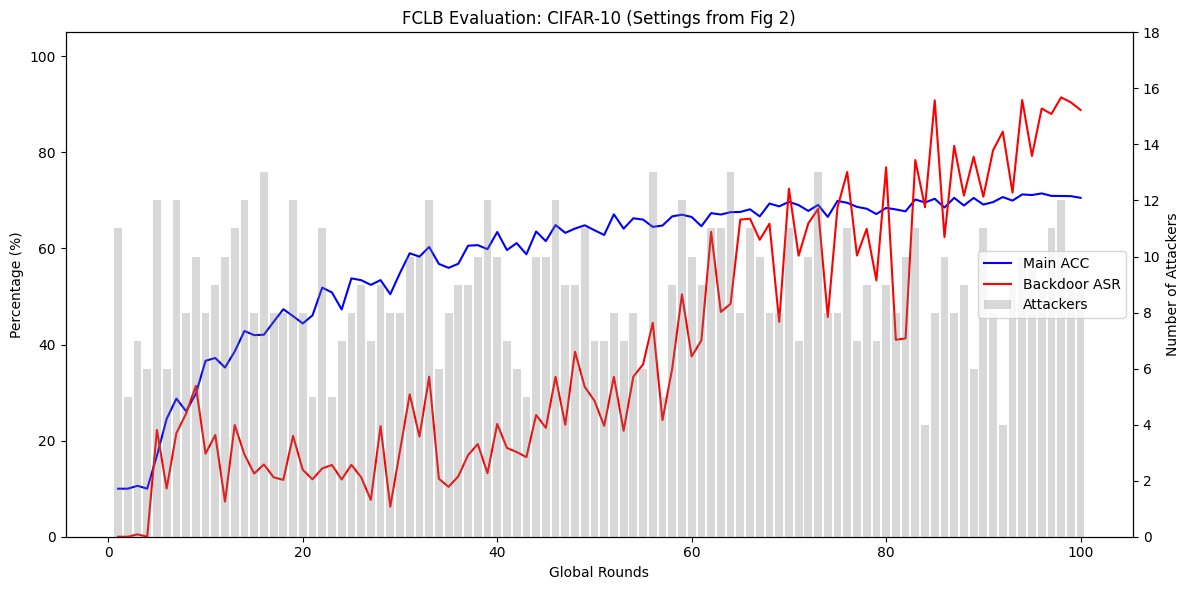

In [ ]:
def main():
    """
    Main execution pipeline for the Constrain-and-Scale (Dirty-Label) Federated Learning simulation.
    
    Arguments:
        None (relies on globally defined helper functions and the Args class).
        
    Returns:
        None
    """
    args = Args()
    set_seed(2026)
    device = get_device()

    print(f"--- Constrain-and-Scale (Dirty-Label) Execution CIFAR-10: Target Class {args.target_class} ---")

    trainset, testset = load_data_cifar10()
    
    pood_raw = get_pood_dataset(size=2000) 
    pood_dataset = ShiftedDataset(pood_raw, shift=10) 
    
    user_groups = get_iid_partitions(trainset, args.num_users)
    analyze_client_distribution(trainset, user_groups, subset_clients=25)

    targets = np.array(trainset.targets)
    target_indices = np.where(targets == args.target_class)[0]
    attacker_knowledge = Subset(trainset, target_indices[:200]) 


    print("\n[1/3] Trigger Optimization on ResNet-18...")
    
    surrogate = get_resnet18_cifar10().to(device)
    
    generator = TriggerGenerator(
        surrogate, pood_dataset, attacker_knowledge, device, 
        target_class_idx=args.target_class, 
        epsilon=args.trigger_epsilon
    )
    
    trigger = generator.generate(t1=args.t1, t2=args.t2, t3=args.t3)

    visualize_trigger_effect_cifar(trainset, trigger, args.target_class)
    log_trigger_power(surrogate, trigger, DataLoader(pood_dataset, batch_size=64), 
                      args.target_class, device)

    print("\n[2/3] Federated Learning Strating round...")
    
    global_model = get_resnet18_cifar10()
    server = Server(device, global_model, testset)
    
    clients = []
    malicious_ids = list(range(args.num_attackers))

    for i in range(args.num_users):
        if i in malicious_ids:
            clients.append(MaliciousClient(
                i, trainset, user_groups[i], device, 
                get_resnet18_cifar10, args, trigger
            ))
        else:
            clients.append(BenignClient(
                i, trainset, user_groups[i], device, get_resnet18_cifar10
            ))

    for rnd in range(1, args.rounds + 1):
        idxs_users = np.random.choice(range(args.num_users), args.clients_per_round, replace=False)
        malicious_selected = sum([1 for idx in idxs_users if idx in malicious_ids])
        
        local_weights = []
        for idx in idxs_users:
            client = clients[idx]
            w = client.update_weights(server.global_model, args.local_ep, args.lr, rnd)
            local_weights.append(w)
            
        server.aggregate(local_weights) 
        
        acc, asr = server.evaluate(trigger, args.target_class)
        server.log_and_plot(rnd, args.clients_per_round, malicious_selected, acc, asr)

    print("\n[3/3] Simulation terminated")
    server.save_final_plots()

if __name__ == '__main__':
    main()